Enter the image's file name:  retina.png


image type is:  <class 'numpy.ndarray'> 
img's shape is:  (2912, 2912, 3) 
img's data type is:  uint8
required memory that the img needs to be saved:  24.2607421875  Mega bytes


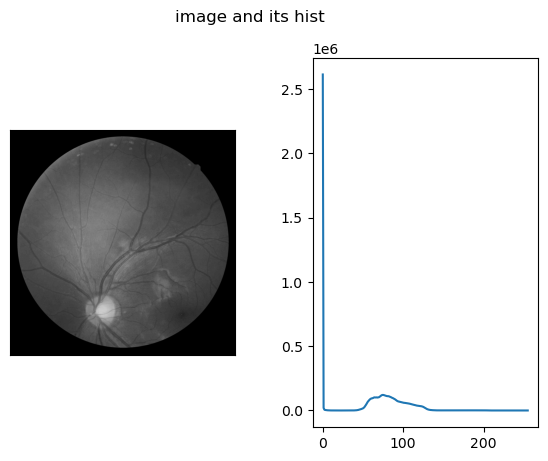

enter the second image name:  retina_sub.png


2095,0
2095,1
2095,2
2095,3
2095,4
2095,5
2095,6
2095,7
2095,8
2095,9
2095,10
2095,11
2095,12
2095,13
2095,14
2095,15
2095,16
2095,17
2095,18
2095,19
2095,20
2095,21
2095,22
2095,23
2095,24
2095,25
2095,26
2095,27
2095,28
2095,29
2095,30
2095,31
2095,32
2095,33
2095,34
2095,35
2095,36
2095,37
2095,38
2095,39
2095,40
2095,41
2095,42
2095,43
2095,44
2095,45
2095,46
2095,47
2095,48
2095,49
2095,50
2095,51
2095,52
2095,53
2095,54
2095,55
2095,56
2095,57
2095,58
2095,59
2095,60
2095,61
2095,62
2095,63
2095,64
2095,65
2095,66
2095,67
2095,68
2095,69
2095,70
2095,71
2095,72
2095,73
2095,74
2095,75
2095,76
2095,77
2095,78
2095,79
2095,80
2095,81
2095,82
2095,83
2095,84
2095,85
2095,86
2095,87
2095,88
2095,89
2095,90
2095,91
2095,92
2095,93
2095,94
2095,95
2095,96
2095,97
2095,98
2095,99
2095,100
2095,101
2095,102
2095,103
2095,104
2095,105
2095,106
2095,107
2095,108
2095,109
2095,110
2095,111
2095,112
2095,113
2095,114
2095,115
2095,116
2095,117
2095,118
2095,119
2095,120
2095,121
2095,122
209

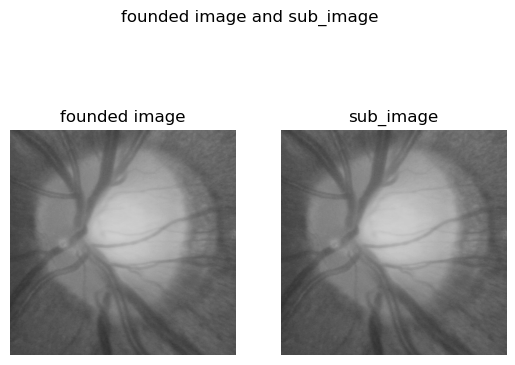

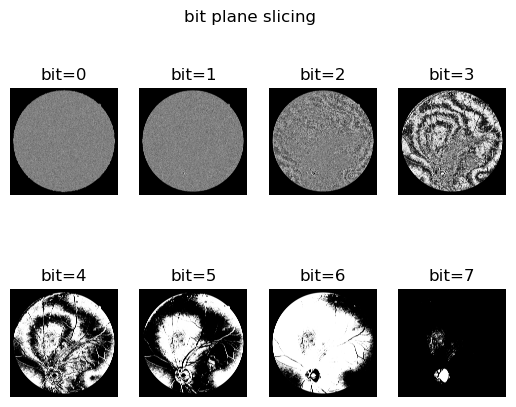

In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

GPU=1
input_name=input("Enter the image's file name: ")
img=cv.imread(input_name)
#cv.imshow("input image",img)
print("image type is: ",type(img),"\nimg's shape is: ",img.shape,"\nimg's data type is: ",img.dtype)
print("required memory that the img needs to be saved: ",img.shape[0]*img.shape[1]*img.shape[2]/1024/1024," Mega bytes")

img_gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
#print(img_gray.shape)

hist_img_gray,_=np.histogram(img_gray, bins=256 , range=(0,255))
#plt.figure()
fig , ax = plt.subplots(1,2)
plt.suptitle("image and its hist")
ax[0].imshow(img_gray,cmap="gray",vmin=0,vmax=255)
ax[0].get_yaxis().set_visible(False), ax[0].get_xaxis().set_visible(False)
ax[1].plot(hist_img_gray)

box=ax[1].get_position()
box.x0=box.x0+0.05
box.x1=box.x1+0.05
ax[1].set_position(box)

plt.show()

input_name2=input("enter the second image name: ")
img_sub=cv.imread(input_name2,cv.IMREAD_GRAYSCALE)
#print(img_sub.shape)

def image_finder(img,img_sub):
    row_num,col_num=img_sub.shape
    first_iteration=1
    #for i in range(img.shape[0]-img_sub.shape[0]+1):
    for i in range(2095,2100):
        for j in range(img.shape[1]-img_sub.shape[1]+1):
            print(i,j,sep=",")
            img_slice=img[i:i+row_num,j:j+col_num]
            hist_slice, _ = np.histogram(img_slice, bins=256, range=(0, 255))
            hist_sub, _ = np.histogram(img_sub, bins=256, range=(0, 255))
            error=np.sum((hist_slice-hist_sub)**2)
            if first_iteration==1:
                optimum_pos=i,j
                minimum_error=error
                first_iteration=0
            else:
                if error<minimum_error:
                    optimum_pos=i,j
                    minimum_error=error
    return optimum_pos

position=image_finder(img_gray,img_sub)
image_slice=img_gray[position[0]:position[0]+img_sub.shape[0],position[1]:position[1]+img_sub.shape[1]]

fig1 , ax1 = plt.subplots(1,2)
plt.suptitle("founded image and sub_image")
ax1[0].imshow(image_slice,cmap="gray",vmin=0,vmax=255)
ax1[0].set_title("founded image")
ax1[0].set_axis_off()
ax1[1].imshow(img_sub,cmap="gray",vmin=0,vmax=255)
ax1[1].set_title("sub_image")
ax1[1].set_axis_off()

plt.show()
"""
def advanced_bit_plane_slicer(image):
    img_0 = np.zeros(image.shape)
    img_1 = np.zeros(image.shape)
    img_2 = np.zeros(image.shape)
    img_3 = np.zeros(image.shape)
    img_4 = np.zeros(image.shape)
    img_5 = np.zeros(image.shape)
    img_6 = np.zeros(image.shape)
    img_7 = np.zeros(image.shape)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if image[i][j]<=1:
                img_0[i][j]=image[i][j]
            elif image[i][j]>1 and image[i][j]<=3:
                img_1[i][j] = image[i][j]
            elif image[i][j] > 3 and image[i][j] <= 7:
                img_2[i][j] = image[i][j]
            elif image[i][j] > 7 and image[i][j] <= 15:
                img_3[i][j] = image[i][j]
            elif image[i][j] > 15 and image[i][j] <= 31:
                img_4[i][j] = image[i][j]
            elif image[i][j] > 31 and image[i][j] <= 63:
                img_5[i][j] = image[i][j]
            elif image[i][j] > 63 and image[i][j] <= 127:
                img_6[i][j] = image[i][j]
            elif image[i][j] > 127 and image[i][j] <= 255:
                img_7[i][j] = image[i][j]
    return img_0.astype(np.uint8),img_1.astype(np.uint8),img_2.astype(np.uint8),img_3.astype(np.uint8),img_4.astype(np.uint8),img_5.astype(np.uint8),img_6.astype(np.uint8),img_7.astype(np.uint8)

slices=advanced_bit_plane_slicer(img_gray)
"""
slices=[255 * ((img & (1<<i)) >>i) for i in range(8)]   # simple bit plane slicing

fig2 , ax2 = plt.subplots(2,4)
plt.suptitle("bit plane slicing")
ax2[0,0].imshow(slices[0],cmap="gray",vmin=0,vmax=255)
ax2[0,0].set_title("bit=0")
ax2[0,0].set_axis_off()
ax2[0,1].imshow(slices[1],cmap="gray",vmin=0,vmax=255)
ax2[0,1].set_title("bit=1")
ax2[0,1].set_axis_off()
ax2[0,2].imshow(slices[2],cmap="gray",vmin=0,vmax=255)
ax2[0,2].set_title("bit=2")
ax2[0,2].set_axis_off()
ax2[0,3].imshow(slices[3],cmap="gray",vmin=0,vmax=255)
ax2[0,3].set_title("bit=3")
ax2[0,3].set_axis_off()
ax2[1,0].imshow(slices[4],cmap="gray",vmin=0,vmax=255)
ax2[1,0].set_title("bit=4")
ax2[1,0].set_axis_off()
ax2[1,1].imshow(slices[5],cmap="gray",vmin=0,vmax=255)
ax2[1,1].set_title("bit=5")
ax2[1,1].set_axis_off()
ax2[1,2].imshow(slices[6],cmap="gray",vmin=0,vmax=255)
ax2[1,2].set_title("bit=6")
ax2[1,2].set_axis_off()
ax2[1,3].imshow(slices[7],cmap="gray",vmin=0,vmax=255)
ax2[1,3].set_title("bit=7")
ax2[1,3].set_axis_off()

plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

